# Exploration modèle — jeu NIST 14 & 16 SEER

Fait suite à `EDA_NIST_descriptive.ipynb`, qui établit : 7375 essais, 5386 lignes mono-défaut
sur 6 classes, 23/24 features atteignables, et **5,3 % de recouvrement** avec le domaine
d'entraînement du simulateur.

Trois questions ici :

1. Les **résidus** mesurés — écart à un cycle sain à condition équivalente (Li & Braun)
2. Les **signes** des signatures mesurées concordent-ils avec le simulateur du projet ?
3. Les classes sont-elles **séparables** sur du réel, et que vaut le protocole de validation ?

> ⚠️ Deux pièges hérités du notebook descriptif :
> `1710_ODSuctPort_psia` est inutilisable sur la 16 SEER (identique au refoulement) — on prend
> `1701_ODVapSV_psia`. Et en mode froid, l'unité **extérieure** est le condenseur.


> **Données non versionnées.** Les deux classeurs NIST (8,5 Mo) ne sont pas dans le dépôt.
> Les télécharger depuis la page publique NIST *Fault Detection and Diagnosis Research Data*
> (URL dans `docs/NIST_MAPPING.md`) et les placer dans `data/nist/` :
>
> - `fdd_1416seer.xlsx` — les 7375 essais
> - `fdd_1416seer_desc.xlsx` — le dictionnaire des 98 colonnes


## 0 — Amorce et reconstruction du jeu


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'requirements.txt').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
NIST = ROOT / 'data' / 'nist'

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white','axes.edgecolor':GRID,
    'axes.labelcolor':MUTED,'text.color':INK,'xtick.color':MUTED,'ytick.color':MUTED,
    'axes.grid':True,'grid.color':GRID,'grid.linewidth':0.8,'axes.axisbelow':True,
    'axes.spines.top':False,'axes.spines.right':False,'font.size':10})

F2C  = lambda s: (s - 32) * 5 / 9
dF2K = lambda s: s * 5 / 9
PSI2BAR, BTU2W = 0.0689476, 0.293071

df = pd.read_excel(NIST / 'fdd_1416seer.xlsx')

FAULTCOLS = {'EF':'Evap_Airflow','CF':'Cond_Blockage','LL':'LiquidLine','UC/OC':'Charge'}
def fault_label(row, tol=2.0):
    active = []
    for col, name in FAULTCOLS.items():
        v = row[col]
        if pd.isna(v) or abs(v - 100) <= tol: continue
        if name == 'Charge': name = 'Undercharge' if v < 100 else 'Overcharge'
        active.append(name)
    if not active: return 'No_Fault'
    return active[0] if len(active) == 1 else 'MULTI:' + '+'.join(sorted(active))
df['fault_class'] = df.apply(fault_label, axis=1)

X = pd.DataFrame(index=df.index)
X['P_evap']         = df['1701_ODVapSV_psia'] * PSI2BAR      # ← pas 1710, cf. descriptif
X['P_cond']         = df['CompDisch_psia'] * PSI2BAR
X['pressure_ratio'] = X.P_cond / X.P_evap
X['T_suction']      = F2C(df['1608_CompSuct_TempF'])
X['T_discharge']    = F2C(df['1617_CompDisch_TempF'])
X['T_evap']         = F2C(df['CompSuct_Tsat_F'])
X['T_cond']         = F2C(df['CompDisch_Tsat_F'])
X['superheat']      = dF2K(df['CompSuct_Suph_F'])
X['subcooling']     = dF2K(df['ODLiqSV_Tsub_F'])
X['Q_evap']         = df['TOTAL Capacity (Btu/h)'] * BTU2W
X['W_od']           = df['OD_Xitron_Watts']
X['COP']            = df['COP']
X['T_source']       = F2C(df['Inlet TC Grid AVG Temp (F)'])  # évaporateur = intérieur
X['T_sink']         = F2C(df['OD Air AVG DB (F)'])           # condenseur  = extérieur
X['delta_T_evap']   = X.T_source - X.T_evap
X['delta_T_cond']   = X.T_cond - X.T_sink
MESURES = list(X.columns)

y, grp = df.fault_class, df.Rated_SEER
keep = (~y.str.startswith('MULTI')) & X.notna().all(axis=1)
X, y, grp = X[keep], y[keep], grp[keep]
print(f'{len(X)} lignes mono-défaut · {len(MESURES)} mesures · {y.nunique()} classes')
print(dict(y.value_counts()))


5387 lignes mono-défaut · 16 mesures · 6 classes
{'No_Fault': np.int64(1353), 'Undercharge': np.int64(1228), 'Overcharge': np.int64(942), 'Evap_Airflow': np.int64(774), 'LiquidLine': np.int64(593), 'Cond_Blockage': np.int64(497)}


## 1 — Résidus mesurés

Méthode Li & Braun : le classifieur travaille sur l'**écart à un cycle sain à condition
équivalente**, pas sur les valeurs absolues. C'est ce que `cycle_to_features(..., baseline=...)`
permet d'injecter dans le projet.

Baseline retenue : médiane des **5 essais sains les plus proches** en (T_source, T_sink),
**dans la même machine**. Volontairement rustique — un vrai modèle de référence (régression
polynomiale sur les essais sains, comme NIST en construit) ferait mieux. Les chiffres qui
suivent sont donc un **plancher**.


In [2]:
from scipy.spatial import cKDTree

RES = ['superheat','subcooling','T_discharge','COP','W_od','P_evap','P_cond','pressure_ratio']
base = pd.DataFrame(index=X.index, columns=RES, dtype=float)
for seer in (14.0, 16.0):
    mm = (grp == seer).values
    nf = mm & (y == 'No_Fault').values
    tree = cKDTree(X.loc[nf, ['T_source','T_sink']].values)
    _, idx = tree.query(X.loc[mm, ['T_source','T_sink']].values, k=5)
    base.loc[mm, RES] = np.median(X.loc[nf, RES].values[idx], axis=1)

Xr = X.copy()
for c in RES:
    Xr['d_' + c] = X[c] - base[c]
Xr = Xr.dropna()
y, grp = y.loc[Xr.index], grp.loc[Xr.index]
D = [c for c in Xr.columns if c.startswith('d_')]
print(f'{len(Xr)} lignes · {len(D)} résidus construits')
Xr[D].describe().loc[['mean','std']].round(3)


5386 lignes · 8 résidus construits


,d_superheat,d_subcooling,d_T_discharge,d_COP,d_W_od,d_P_evap,d_P_cond,d_pressure_ratio
mean,1.958,0.186,3.127,-0.047,47.608,-0.129,0.470,0.073
std,5.339,2.675,7.045,0.353,212.115,0.490,2.276,0.208


## 2 — Concordance des signes : mesuré vs simulé

Pour chaque défaut, on régresse chaque grandeur sur le **niveau de défaut**, avec `T_source`
et `T_sink` en covariables pour neutraliser les conditions d'essai. On compare le signe du
coefficient au balayage du simulateur du projet.


In [3]:
from src.physics.simulator import HeatPumpSimulator

FEATS = ['superheat','subcooling','T_discharge','COP','W_comp','P_evap','P_cond']
COLS  = dict(zip(FEATS, ['superheat','subcooling','T_discharge','COP','W_od','P_evap','P_cond']))
NIVEAU = {'Cond_Blockage': 100 - df.CF, 'Evap_Airflow': 100 - df.EF,
          'Undercharge': 100 - df['UC/OC'], 'Overcharge': df['UC/OC'] - 100}

mesure = {}
for cls, niv in NIVEAU.items():
    m = (y == cls) | (y == 'No_Fault')
    lvl = niv.loc[Xr.index].where(y == cls, 0.0)[m]
    pentes = []
    for f in FEATS:
        d = pd.concat([lvl.rename('lvl'), Xr.loc[m, [COLS[f], 'T_source', 'T_sink']]], axis=1).dropna()
        A = np.c_[np.ones(len(d)), d.lvl, d.T_source, d.T_sink]
        pentes.append(np.linalg.lstsq(A, d[COLS[f]].values, rcond=None)[0][1])
    mesure[cls] = pentes

sim = HeatPumpSimulator()
BALAYAGE = {'Cond_Blockage': ('condenser_fouling',  np.linspace(0, .45, 10)),
            'Evap_Airflow':  ('fan_evap_ratio',     np.linspace(1, .60, 10)),
            'Undercharge':   ('refrigerant_charge', np.linspace(1, .70, 10)),
            'Overcharge':    ('refrigerant_charge', np.linspace(1, 1.30, 10))}
simule = {}
for cls, (param, vals) in BALAYAGE.items():
    A = np.array([[getattr(sim.simulate_cycle(T_source=7, T_sink=40, speed_ratio=.7,
                                              **{param: float(v)}), f) for f in FEATS] for v in vals])
    lvl = np.abs(vals - vals[0])
    simule[cls] = [np.polyfit(lvl, A[:, i], 1)[0] for i in range(len(FEATS))]

sgn = lambda x, eps: 0 if abs(x) < eps else (1 if x > 0 else -1)
SYM = {1: '+', -1: '−', 0: '0'}
lignes, ok, tot = [], 0, 0
for cls in mesure:
    row = {'défaut': cls}
    for i, f in enumerate(FEATS):
        sm, ss = sgn(mesure[cls][i], 1e-4), sgn(simule[cls][i], 1e-9)
        if ss == 0:
            row[f] = f'{SYM[sm]} / ∅'
        else:
            tot += 1; bon = sm == ss; ok += bon
            row[f] = f"{SYM[sm]} / {SYM[ss]} {'OK' if bon else 'NON'}"
    lignes.append(row)
print(f'accord global : {ok}/{tot}  ({100*ok/tot:.0f} %)')
print('∅ = le simulateur ne produit aucun signal (pente nulle)')
pd.DataFrame(lignes).set_index('défaut')


accord global : 12/16  (75 %)
∅ = le simulateur ne produit aucun signal (pente nulle)


,superheat,subcooling,T_discharge,COP,W_comp,P_evap,P_cond
défaut,,,,,,,
Cond_Blockage,+ / ∅,+ / − NON,+ / + OK,− / − OK,+ / + OK,+ / ∅,+ / + OK
Evap_Airflow,− / + NON,− / ∅,− / + NON,− / − OK,− / − OK,− / − OK,− / ∅
Undercharge,+ / + OK,− / − OK,+ / + OK,− / − OK,+ / − NON,− / − OK,− / ∅
Overcharge,− / ∅,+ / ∅,+ / ∅,+ / ∅,+ / ∅,− / ∅,+ / ∅


### Trois erreurs de modélisation nommées

1. **La surcharge n'est pas modélisée.** Toutes les pentes simulées sont nulles :
   `simulator.py` ne traite que `refrigerant_charge < 1.0`. `REFRIGERANT_OVERCHARGE` est
   décoratif, et 942 essais réels de surcharge sont incomparables.
2. **Le sous-refroidissement de l'obstruction condenseur est inversé.** Obstruer un condenseur
   fait s'accumuler le liquide, donc **monter** le sous-refroidissement — ce que mesure NIST.
   Le simulateur le fait descendre. Or `d_subcooling` est une des features du modèle.
3. **Le défaut de débit évaporateur a deux signes inversés** (`superheat`, `T_discharge`).
   Le terme `+ 8.0 * (1.0 - fan_evap_ratio)` sur le pincement pousse dans le mauvais sens.


## 3 — Séparabilité et protocole de validation

⚠️ **Aucune colonne de niveau de défaut** (`EF`, `CF`, `LL`, `UC/OC`) n'entre dans `X` —
ce serait une fuite de cible.

Deux protocoles comparés :

- **CV aléatoire stratifiée** — mélange les deux machines, donc *optimiste*
- **Leave-one-machine-out** — entraîner sur une machine, tester sur l'autre, donc *honnête*


In [4]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score

modele = lambda: GradientBoostingClassifier(random_state=42)
JEUX = {'brutes': MESURES,
        'brutes + résidus': MESURES + D,
        'résidus seuls': D,
        'résidus + conditions': D + ['T_source', 'T_sink']}

res = []
for nom, cols in JEUX.items():          # ~1 à 2 minutes au total
    F = Xr[cols]
    cv = cross_val_score(modele(), F, y, scoring='accuracy',
                         cv=StratifiedKFold(5, shuffle=True, random_state=42)).mean()
    s = []
    for test in (14.0, 16.0):
        tr, te = grp != test, grp == test
        pred = modele().fit(F[tr], y[tr]).predict(F[te])
        s.append((accuracy_score(y[te], pred), f1_score(y[te], pred, average='macro')))
    res.append({'jeu de features': nom,
                'CV aléatoire': round(cv, 3),
                'leave-1-machine-out': round(np.mean([a for a, _ in s]), 3),
                'f1 macro (LOMO)': round(np.mean([f for _, f in s]), 3)})

MAJ = y.value_counts(normalize=True).max()
print(f'classe majoritaire : {MAJ:.3f}  ← référence basse')
perf = pd.DataFrame(res).set_index('jeu de features'); perf


classe majoritaire : 0.251  ← référence basse


,CV aléatoire,leave-1-machine-out,f1 macro (LOMO)
jeu de features,,,
brutes,0.954,0.333,0.282
brutes + résidus,0.973,0.562,0.423
résidus seuls,0.937,0.602,0.479
résidus + conditions,0.945,0.594,0.479


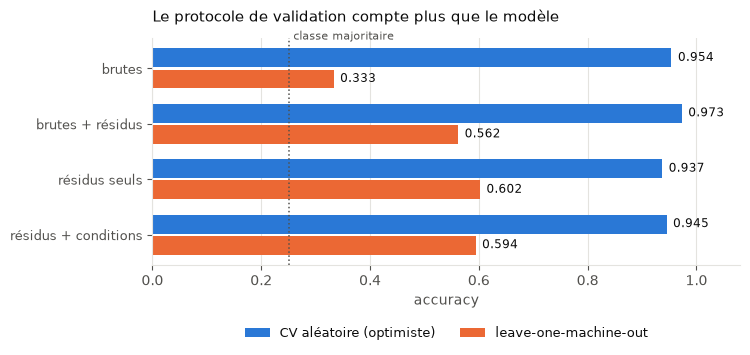

In [5]:
fig, ax = plt.subplots(figsize=(7.6, 3.8))
ypos = np.arange(len(perf))[::-1]; h = 0.34
ax.barh(ypos + h/2 + .02, perf['CV aléatoire'], height=h, color=BLUE,
        label='CV aléatoire (optimiste)')
ax.barh(ypos - h/2 - .02, perf['leave-1-machine-out'], height=h, color=ORANGE,
        label='leave-one-machine-out')
for yy, (a, b) in zip(ypos, perf[['CV aléatoire', 'leave-1-machine-out']].values):
    ax.text(a + .012, yy + h/2 + .02, f'{a:.3f}', va='center', fontsize=8.5, color=INK)
    ax.text(b + .012, yy - h/2 - .02, f'{b:.3f}', va='center', fontsize=8.5, color=INK)
ax.axvline(MAJ, color=MUTED, linestyle=':', linewidth=1.1)
ax.text(MAJ + .008, ypos.max() + .52, 'classe majoritaire', fontsize=8, color=MUTED)
ax.set_yticks(ypos); ax.set_yticklabels(perf.index, fontsize=9)
ax.set_xlim(0, 1.08); ax.set_xlabel('accuracy'); ax.grid(axis='y', visible=False)
ax.set_title('Le protocole de validation compte plus que le modèle',
             loc='left', fontsize=11, color=INK, pad=12)
ax.legend(frameon=False, fontsize=9, ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.22))
plt.tight_layout()


## 4 — Verdict

| Question | Réponse |
|---|---|
| Volume pour réentraîner ? | **Oui** — 5386 lignes mono-défaut, 6 classes, équilibre 2,7:1 |
| Signes concordants avec le simulateur ? | **12/16 (75 %)**, 3 erreurs nommées |
| Classes séparables sur du réel ? | **Partiellement** — 0,60 en transfert inter-machine |

### Le résultat central

**Les résidus font presque doubler le transfert entre machines : 0,333 → 0,602**, pour
1,7 point perdu en CV aléatoire. C'est la validation empirique, sur mesures réelles, du choix
Li & Braun qui structure `src/fdd/features.py`. Jusqu'ici c'était un argument théorique.

**Ajouter les grandeurs brutes aux résidus dégrade le transfert** (0,602 → 0,562) : les valeurs
absolues laissent le modèle ré-identifier la machine. Or `FEATURE_COLUMNS` mélange aujourd'hui
19 grandeurs absolues et 5 résidus — à reconsidérer.

### Ce que dit le protocole

**0,95 en CV aléatoire contre 0,60 en leave-one-machine-out.** Une validation par mélange
aléatoire mesure autant l'installation que le défaut. C'est le même piège que la circularité
du simulateur, sous une autre forme — et il est ici **mesuré**, pas supposé.

### Suite

Remplacer le baseline plus-proche-voisin par un vrai modèle de référence sain (régression
polynomiale sur les essais sans défaut) et mesurer jusqu'où le transfert monte.
**0,602 est un plancher.**
